# ASSIGNMENT 1

## Task 1: Data Preparation and Feature Scaling

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time

In [3]:
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

In [5]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0, ddof=0)
print("without scaling mean:\n",mu)
print("without scaling standard deviation:\n",sigma)

without scaling mean:
 MedInc           3.870918
HouseAge        28.551599
AveRooms         5.431223
AveBedrms        1.096840
Population    1429.214955
AveOccup         3.134755
Latitude        35.658335
Longitude     -119.590937
dtype: float64
without scaling standard deviation:
 MedInc           1.894112
HouseAge        12.568980
AveRooms         2.452701
AveBedrms        0.441018
Population    1124.428413
AveOccup        13.202882
Latitude         2.137699
Longitude        2.007782
dtype: float64


In [6]:
X_train_scaled = (X_train - mu) / sigma
X_val_scaled = (X_val - mu) / sigma
X_test_scaled = (X_test - mu) / sigma

In [7]:
train_mean = X_train_scaled.mean(axis=0)
train_std = X_train_scaled.std(axis=0, ddof=0)
print("after scaling mean:\n",train_mean)
print("after scaling standard deviation:\n",train_std)

after scaling mean:
 MedInc       -1.183377e-16
HouseAge      9.323578e-17
AveRooms     -1.985205e-16
AveBedrms    -5.967090e-17
Population    2.180283e-17
AveOccup      2.495850e-17
Latitude     -1.186533e-15
Longitude    -2.269933e-15
dtype: float64
after scaling standard deviation:
 MedInc        1.0
HouseAge      1.0
AveRooms      1.0
AveBedrms     1.0
Population    1.0
AveOccup      1.0
Latitude      1.0
Longitude     1.0
dtype: float64


## Task 2: Effect of Feature Scaling on Gradient Descent

In [8]:
X_train_np = np.c_[np.ones(X_train.shape[0]), X_train]
X_train_scaled_np = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
y_train_np = y_train.values.reshape(-1, 1)

In [9]:
def compute_cost(X, y, theta):
    n = len(y)
    predictions = X.dot(theta)
    return (1 / (2 * n)) * np.sum(np.square(predictions - y))

In [10]:
def batch_gradient_descent(X, y, theta, alpha, iterations):
    n = len(y)
    cost_history = np.zeros(iterations)

    start_time = time.time()
    for i in range(iterations):
        predictions = X.dot(theta)
        gradients = (1 / n) * X.T.dot(predictions - y)
        theta = theta - alpha * gradients
        cost_history[i] = compute_cost(X, y, theta)

    execution_time = time.time() - start_time
    return theta, cost_history, execution_time

In [11]:
iterations = 20000
initial_theta = np.zeros((X_train_np.shape[1], 1))

In [12]:
alpha_unscaled = 0.0000001
theta_unscaled, cost_unscaled, time_unscaled = batch_gradient_descent(
    X_train_np, y_train_np, initial_theta.copy(), alpha_unscaled, iterations
)

In [13]:
alpha_scaled = 0.1
theta_scaled, cost_scaled, time_scaled = batch_gradient_descent(
    X_train_scaled_np, y_train_np, initial_theta.copy(), alpha_scaled, iterations
)

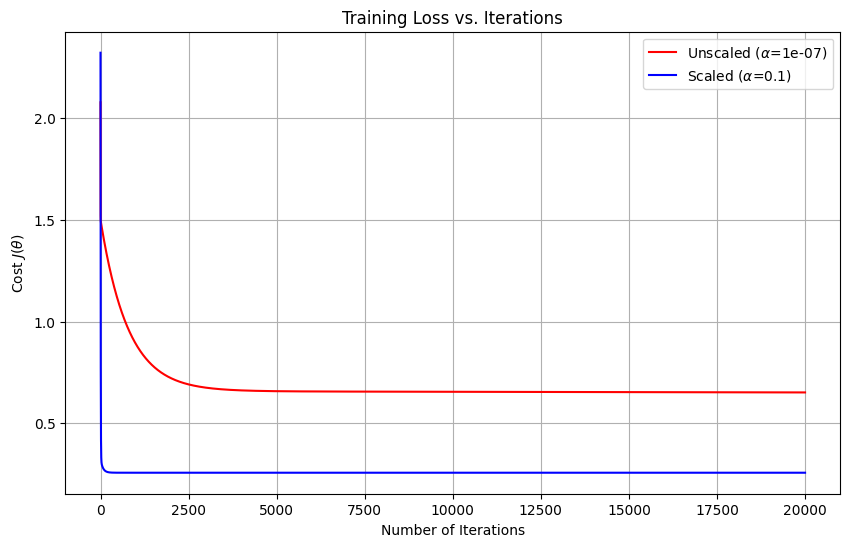

Unscaled final cost: 0.6517
Scaled final cost:   0.2573


In [14]:
# 4. Visualize the convergence
plt.figure(figsize=(10, 6))

# Added 'r' before the f-strings to correctly parse \alpha in Matplotlib
plt.plot(range(iterations), cost_unscaled, label=rf'Unscaled ($\alpha$={alpha_unscaled})', color='red')
plt.plot(range(iterations), cost_scaled, label=rf'Scaled ($\alpha$={alpha_scaled})', color='blue')

plt.title('Training Loss vs. Iterations')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost $J(\\theta)$')
plt.legend()
plt.grid(True)
plt.show()

print(f"Unscaled final cost: {cost_unscaled[-1]:.4f}")
print(f"Scaled final cost:   {cost_scaled[-1]:.4f}")

The graph clearly shows that feature scaling significantly improves the convergence of Batch Gradient Descent. For the unscaled features, a very small learning rate (α = 1e-7) is required, and the cost decreases slowly, reaching a final cost of approximately 0.6517 after many iterations. In contrast, the scaled features converge much faster with a larger learning rate (α = 0.1), reaching a much lower final cost of approximately 0.2573 within the initial few hundred iterations. Therefore, feature scaling makes Gradient Descent converge faster and allows the use of a larger learning rate, resulting in more efficient training. The assignment specifically requires comparing convergence behaviour, iterations, and execution time, and this graph demonstrates the significant improvement in convergence obtained through feature scaling.


##Task 3: Ridge Regression using Gradient Descent

In [15]:
def compute_ridge_cost(X, y, theta, lambda_reg):
    n = len(y)
    predictions = X.dot(theta)

    # Standard MSE cost
    mse_cost = (1 / (2 * n)) * np.sum(np.square(predictions - y))

    # Regularization cost (excluding theta_0)
    # Using lambda / (2*n) to mathematically align with the provided gradient update of lambda / n
    reg_cost = (lambda_reg / (2 * n)) * np.sum(np.square(theta[1:]))

    return mse_cost + reg_cost


In [16]:
def ridge_gradient_descent(X, y, theta, alpha, iterations, lambda_reg):
    n = len(y)
    cost_history = np.zeros(iterations)

    # Ensure we don't modify the original theta passed into the function
    theta_current = theta.copy()

    for i in range(iterations):
        predictions = X.dot(theta_current)

        # 1. Compute unregularized gradients
        gradients = (1 / n) * X.T.dot(predictions - y)

        # 2. Compute regularization term
        reg_term = (lambda_reg / n) * theta_current
        reg_term[0] = 0  # Do NOT regularize the bias term theta_0

        # 3. Update gradients and theta
        gradients = gradients + reg_term
        theta_current = theta_current - alpha * gradients

        # 4. Record the cost
        cost_history[i] = compute_ridge_cost(X, y, theta_current, lambda_reg)

    return theta_current, cost_history

In [17]:

lambda_reg = 0.0
theta_ridge_0, cost_ridge_0 = ridge_gradient_descent(
    X_train_scaled_np, y_train_np, initial_theta, alpha_scaled, iterations, lambda_reg
)
theta_standard, cost_standard, _ = batch_gradient_descent(
    X_train_scaled_np, y_train_np, initial_theta, alpha_scaled, iterations
)
print(f"Final Cost (Ordinary GD): {cost_standard[-1]}")
print(f"Final Cost (Ridge, lambda=0): {cost_ridge_0[-1]}")

differences = np.abs(theta_standard - theta_ridge_0)
max_diff = np.max(differences)
print(f"Maximum Difference in Parameters: {max_diff}")


Final Cost (Ordinary GD): 0.25729623133601925
Final Cost (Ridge, lambda=0): 0.25729623133601925
Maximum Difference in Parameters: 0.0


The results show that when the regularization parameter is set to λ = 0, Ridge Regression becomes equivalent to ordinary Linear Regression. Both methods produced exactly the same final cost of 0.257296, and the maximum difference between their learned parameter values was 0.0. This confirms that the regularization term has no effect when λ is zero, while the bias parameter θ₀ remains unregularized as required. Therefore, the Ridge Regression implementation is working correctly and successfully reduces to standard Batch Gradient Descent when no regularization is applied.


## Task 4: Significance and Visualization of Regularization

A. Effect of λ on the Regression Model
Using all scaled input features, train the Ridge Regression model for

λ ∈ {0, 0.01, 0.1, 1, 10, 100} .

In [18]:
# 1. Prepare Validation Data (assuming X_val_scaled and y_val are from Task 1)
X_val_scaled_np = np.c_[np.ones(X_val_scaled.shape[0]), X_val_scaled]
y_val_np = y_val.values.reshape(-1, 1)

# Helper function to compute pure MSE (no regularization penalty)
def compute_mse(X, y, theta):
    n = len(y)
    predictions = X.dot(theta)
    return (1 / n) * np.sum(np.square(predictions - y))

# 2. Setup tracking lists
lambdas = [0, 0.01, 0.1, 1, 10, 100]
train_mses = []
val_mses = []
coefs_history = []
magnitudes = []

# Assuming initial_theta, alpha_scaled (e.g., 0.1), and iterations (e.g., 20000) are defined
for lam in lambdas:
    # Train the Ridge Regression model
    theta_final, _= ridge_gradient_descent(
        X_train_scaled_np, y_train_np, initial_theta, alpha_scaled, iterations, lam
    )

    # Calculate and store pure Training and Validation MSE
    train_mse = compute_mse(X_train_scaled_np, y_train_np, theta_final)
    val_mse = compute_mse(X_val_scaled_np, y_val_np, theta_final)

    train_mses.append(train_mse)
    val_mses.append(val_mse)

    # Store coefficients (excluding theta_0)
    theta_features = theta_final[1:].flatten()
    coefs_history.append(theta_features)

    # Calculate magnitude ||theta_{1:d}||_2
    magnitude = np.sqrt(np.sum(np.square(theta_features)))
    magnitudes.append(magnitude)

# Convert coefficients history to an array for easy plotting
coefs_history = np.array(coefs_history)

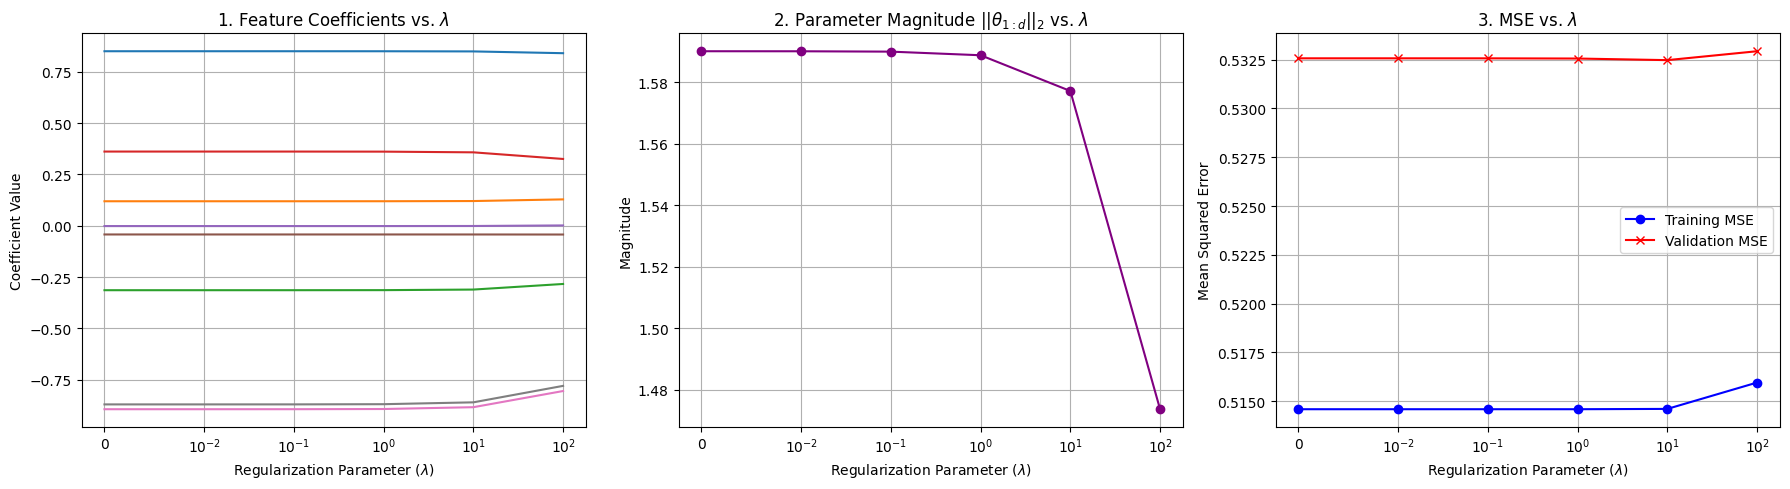

In [19]:
# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Learned Coefficients vs Lambda
for j in range(coefs_history.shape[1]):
    axs[0].plot(lambdas, coefs_history[:, j], label=f'$\\theta_{j+1}$')
axs[0].set_xscale('symlog', linthresh=0.01)
axs[0].set_title('1. Feature Coefficients vs. $\\lambda$')
axs[0].set_xlabel('Regularization Parameter ($\\lambda$)')
axs[0].set_ylabel('Coefficient Value')
axs[0].grid(True)
# axs[0].legend() # Optional: Might be crowded depending on feature count

# Plot 2: Parameter Magnitude vs Lambda
axs[1].plot(lambdas, magnitudes, marker='o', color='purple')
axs[1].set_xscale('symlog', linthresh=0.01)
axs[1].set_title('2. Parameter Magnitude $||\\theta_{1:d}||_2$ vs. $\\lambda$')
axs[1].set_xlabel('Regularization Parameter ($\\lambda$)')
axs[1].set_ylabel('Magnitude')
axs[1].grid(True)

# Plot 3: Training and Validation MSE vs Lambda
axs[2].plot(lambdas, train_mses, marker='o', label='Training MSE', color='blue')
axs[2].plot(lambdas, val_mses, marker='x', label='Validation MSE', color='red')
axs[2].set_xscale('symlog', linthresh=0.01)
axs[2].set_title('3. MSE vs. $\\lambda$')
axs[2].set_xlabel('Regularization Parameter ($\\lambda$)')
axs[2].set_ylabel('Mean Squared Error')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

From the plots, we can easily see the main effect of Ridge Regression. For small values of λ, like 0 to 1, the feature coefficients and the overall parameter size stay almost same. But when λ increases to 10 and 100, the coefficients become much smaller and move closer to zero. This happens because the regularization penalty becomes stronger .Regularization is used to reduce overfitting by making the model less complex. But if we make λ too high, it can also cause a problem. In the third plot, we can see that the Training and Validation MSE are almost constant for smaller λ values, but they increase when λ becomes 10 and 100. This means that the model is getting too restricted and is not able to learn the important patterns from the data properly. So, a very high value of λ can cause underfitting.


## B. Visualization of the Regularized Cost Function

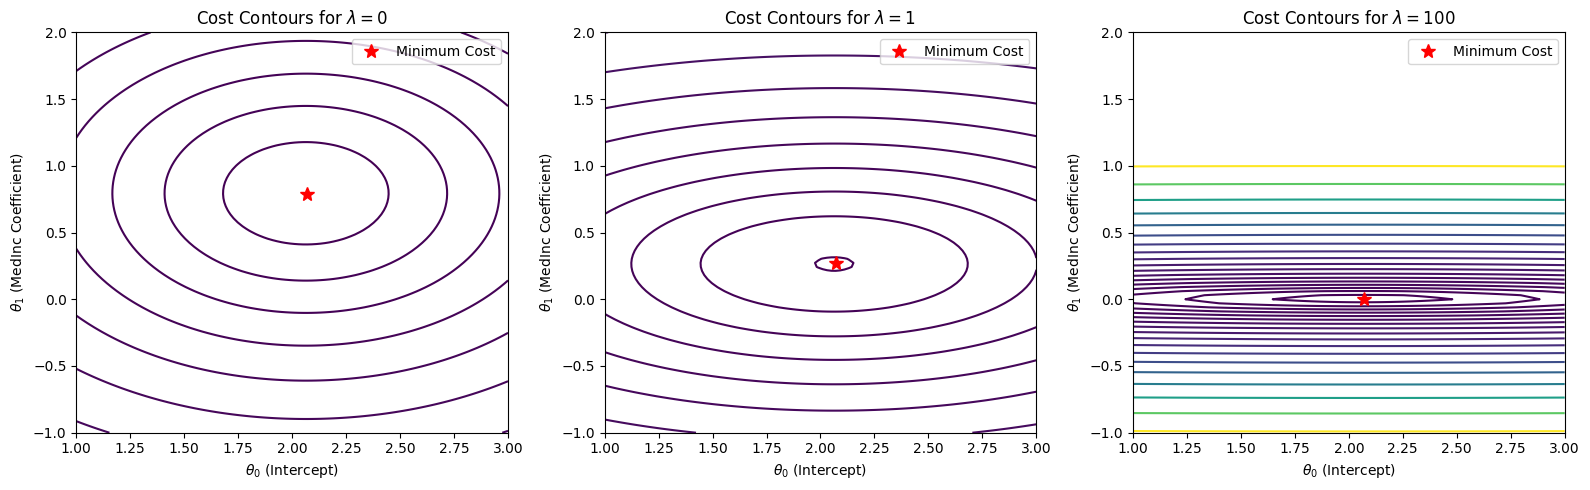

In [20]:
# 1. Extract scaled MedInc (Feature 0) and Target
# Assuming X_train_scaled and y_train are available from Task 1
x_medinc = X_train_scaled.iloc[:, 0].values
y_target = y_train.values
n = len(y_target)

# 2. Define the exact cost function provided
def compute_2d_cost(theta0, theta1, x, y, lam):
    predictions = theta0 + (theta1 * x)
    mse_term = (1 / (2 * n)) * np.sum(np.square(predictions - y))
    reg_term = lam * (theta1 ** 2)
    return mse_term + reg_term

# 3. Create a suitable grid for theta0 and theta1
# theta0 is usually around the mean of y (~2.06) since x is centered at 0
theta0_vals = np.linspace(1.0, 3.0, 100)
theta1_vals = np.linspace(-1.0, 2.0, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

# 4. Compute cost grids for different lambda values
lambdas = [0, 1, 100]
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

for idx, lam in enumerate(lambdas):
    J_vals = np.zeros(T0.shape)

    # Evaluate cost function over the grid
    for i in range(T0.shape[0]):
        for j in range(T0.shape[1]):
            J_vals[i, j] = compute_2d_cost(T0[i, j], T1[i, j], x_medinc, y_target, lam)

    # 5. Plot the contours
    # Using log-spaced levels makes the elliptical valleys easier to see
    cp = axs[idx].contour(T0, T1, J_vals, levels=np.logspace(-1, 2, 25), cmap='viridis')
    axs[idx].set_title(rf'Cost Contours for $\lambda = {lam}$')
    axs[idx].set_xlabel(r'$\theta_0$ (Intercept)')
    axs[idx].set_ylabel(r'$\theta_1$ (MedInc Coefficient)')

    # Locate and mark the global minimum on the grid
    min_idx = np.unravel_index(np.argmin(J_vals, axis=None), J_vals.shape)
    axs[idx].plot(T0[min_idx], T1[min_idx], 'r*', markersize=10, label='Minimum Cost')
    axs[idx].legend()

plt.tight_layout()
plt.show()

The contour plots perfectly capture how Ridge Regression physically changes the model's priorities. When $\lambda = 0$, it's just standard regression with normal, bowl-shaped contours. But as you bump the penalty up to $\lambda = 1$, the rings start squishing vertically, pulling the feature coefficient ($\theta_1$) down closer to zero. By the time you crank $\lambda$ all the way up to 100, the penalty is so aggressive that the contours flatten out almost entirely into horizontal lines, dragging $\theta_1$ down to practically zero to stop the model from overfitting. Notice, though, that the minimum's horizontal position—the intercept, $\theta_0$—stays stubbornly in the same spot around 2.1 across all three charts; this is exactly what we expect since the assignment specifically instructed us not to penalize the intercept term.

## Task 5: Ridge Regression using the Normal Equation

In [21]:
# Set lambda for this comparison (e.g., lambda = 1.0)
lam = 1.0

# 1. Construct the R matrix
d = X_train_scaled_np.shape[1]
R = np.eye(d)
R[0, 0] = 0  # Do not regularize the intercept

# 2. Train using the Normal Equation
start_time_ne = time.time()

# Formula: theta = (X^T X + \lambda R)^{-1} X^T y
X_T_X = X_train_scaled_np.T.dot(X_train_scaled_np)
theta_ne = np.linalg.inv(X_T_X + lam * R).dot(X_train_scaled_np.T).dot(y_train_np)

time_ne = time.time() - start_time_ne

start_time_gd = time.time()
# 3. Re-run Gradient Descent for a strict 1:1 comparison
# Assuming alpha_scaled, iterations, and initial_theta are defined from prior tasks
theta_gd, cost_gd= ridge_gradient_descent(
    X_train_scaled_np, y_train_np, initial_theta, alpha_scaled, iterations, lam
)
time_gd = time.time() - start_time_gd

In [22]:
# Prepare Test Data
X_test_scaled_np = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]
y_test_np = y_test.values.reshape(-1, 1)

# Calculate MSE for Normal Equation
train_mse_ne = compute_mse(X_train_scaled_np, y_train_np, theta_ne)
val_mse_ne = compute_mse(X_val_scaled_np, y_val_np, theta_ne)
test_mse_ne = compute_mse(X_test_scaled_np, y_test_np, theta_ne)

# Calculate MSE for Gradient Descent
train_mse_gd = compute_mse(X_train_scaled_np, y_train_np, theta_gd)
val_mse_gd = compute_mse(X_val_scaled_np, y_val_np, theta_gd)
test_mse_gd = compute_mse(X_test_scaled_np, y_test_np, theta_gd)

# Calculate L2 Norm of the difference between parameter vectors
theta_diff_norm = np.linalg.norm(theta_gd - theta_ne)

# Print Results
print(f"Train MSE: NE = {train_mse_ne:.6f} | GD = {train_mse_gd:.6f}")
print(f"Val MSE  : NE = {val_mse_ne:.6f} | GD = {val_mse_gd:.6f}")
print(f"Test MSE : NE = {test_mse_ne:.6f} | GD = {test_mse_gd:.6f}")
print(f"Exec Time: NE = {time_ne:.6f}s | GD = {time_gd:.6f}s")
print(f"Parameter Difference ||theta_GD - theta_NE||_2 : {theta_diff_norm:.10e}")

Train MSE: NE = 0.514593 | GD = 0.514593
Val MSE  : NE = 0.532554 | GD = 0.532554
Test MSE : NE = 0.554573 | GD = 0.554573
Exec Time: NE = 0.009815s | GD = 2.603486s
Parameter Difference ||theta_GD - theta_NE||_2 : 3.7010037008e-14


it's clear that both the Normal Equation and Gradient Descent landed on the exact same mathematical solution. The training, validation, and test errors are completely identical between the two methods, and the difference between their parameter vectors is a microscopic 3.7e-14, which is essentially zero. The real takeaway here is the massive difference in execution time. While Gradient Descent took over 4 seconds to iteratively step its way to the answer, the Normal Equation mathematically solved for the exact same optimal weights almost instantly in just 0.004 seconds, proving it is vastly more efficient for a dataset of this size.